# Task 1: Exploratory Data Analysis
### ACIS Insurance Risk Analytics — Week 3 Challenge

This notebook explores 18 months (Feb 2014 – Aug 2015) of ACIS car-insurance
policy, client, vehicle, and claim data to uncover risk and profitability
patterns that will inform segmentation and pricing strategy.

**Guiding questions answered in this notebook:**
1. What is the overall Loss Ratio for the portfolio? How does it vary by Province, VehicleType, and Gender?
2. What are the distributions of key financial variables? Are there outliers in TotalClaims or SumInsured that could skew analysis?
3. Are there temporal trends? Did claim frequency or severity change over the 18-month period?
4. Which vehicle makes/models are associated with the highest and lowest claim amounts?


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_insurance_data, add_risk_metrics, missing_value_report, get_numeric_columns, get_categorical_columns
from src.eda_utils import (
    overall_loss_ratio, loss_ratio_by_group, plot_loss_ratio_by_group,
    plot_numeric_distribution, plot_categorical_counts, plot_outliers_boxplot,
    monthly_trend, plot_monthly_trend, top_bottom_by_claims, correlation_matrix
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

## 1. Data Summarization

Load the dataset, confirm shape and dtypes, and generate descriptive statistics for numerical features.

In [2]:
df = load_insurance_data('../data/cleaned_data.csv')
df = add_risk_metrics(df)
print(f"Shape: {df.shape}")
df.head()

c:\Users\user 1\Desktop\insurance-risk-analytics\notebooks\..\src\data_loader.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


Shape: (618176, 51)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,2002-06-01,Yes,No,119300,More than 6 months,No,No,No,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,2002-06-01,Yes,No,119300,More than 6 months,No,No,No,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,2002-06-01,Yes,No,119300,More than 6 months,No,No,No,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
3,145247,12827,2015-01-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,2002-06-01,Yes,No,119300,More than 6 months,No,No,No,500000.00,Monthly,57.5412,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.256435,0.0,0.0,3.256435
4,145247,12827,2015-04-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,2002-06-01,Yes,No,119300,More than 6 months,No,No,No,500000.00,Monthly,57.5412,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,50.474737,0.0,0.0,50.474737


In [3]:
df.dtypes

UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                       bool
Citizenship                            str
LegalType                              str
Title                                  str
Language                               str
Bank                                   str
AccountType                            str
MaritalStatus                          str
Gender                                 str
Country                                str
Province                               str
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
mmcode                             float64
VehicleType                            str
RegistrationYear                     int64
make                                   str
Model                                  str
Cylinders  

In [4]:
# Descriptive statistics for key numerical features
numeric_cols = ['TotalPremium', 'TotalClaims', 'LossRatio', 'Margin', 'SumInsured', 'CalculatedPremiumPerTerm']
df[numeric_cols].describe()

,TotalPremium,TotalClaims,LossRatio,Margin,SumInsured,CalculatedPremiumPerTerm
count,618176.000000,618176.000000,618176.000000,618176.000000,6.181760e+05,618176.000000
mean,100.203033,100.413265,0.350048,-0.210232,6.098269e+05,118.536058
std,286.236094,2989.980798,9.288639,2968.679190,1.515211e+06,344.710273
min,0.000011,-12002.412281,-18.700122,-392848.566930,1.000000e-02,0.000200
25%,2.631316,0.000000,0.000000,2.578246,5.000000e+03,3.255100
50%,7.281228,0.000000,0.000000,7.210614,7.500000e+03,8.436900
75%,78.947368,0.000000,0.000000,78.947368,2.505000e+05,90.000000
max,65282.603421,393092.105263,2553.600000,65282.603421,1.263620e+07,74422.167900


## 2. Data Quality Assessment

Check for missing values and document the handling strategy.

In [5]:
report = missing_value_report(df)
report

,missing_count,missing_pct
mmcode,218,0.035
VehicleType,218,0.035
make,218,0.035
Model,218,0.035
Cylinders,218,0.035
cubiccapacity,218,0.035
kilowatts,218,0.035
bodytype,218,0.035
NumberOfDoors,218,0.035
VehicleIntroDate,218,0.035


**Handling strategy:** Missing values are concentrated in vehicle-related fields
(`make`, `Model`, `VehicleType`, `Cylinders`, `cubiccapacity`, `kilowatts`, `bodytype`,
`NumberOfDoors`, `VehicleIntroDate`, `mmcode`) at ~0.04% of rows (218 out of 618,176) —
negligible in volume. These rows likely correspond to policies where vehicle
specification wasn't fully captured at underwriting. Since the proportion is
tiny, we drop rows missing vehicle detail for vehicle-level analyses, but keep
them for portfolio-level (province/gender) analyses where vehicle fields
aren't required. `CapitalOutstanding` has only 2 missing values and is
excluded from numeric analysis, treated as an object field.

In [6]:
vehicle_cols = ['make', 'Model', 'VehicleType', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors']
df_vehicle_complete = df.dropna(subset=vehicle_cols)
print(f"Rows with complete vehicle info: {len(df_vehicle_complete)} / {len(df)} ({len(df_vehicle_complete)/len(df)*100:.2f}%)")

Rows with complete vehicle info: 617958 / 618176 (99.96%)


## 3. Univariate Analysis

Histograms for numerical columns and bar charts for categorical columns.

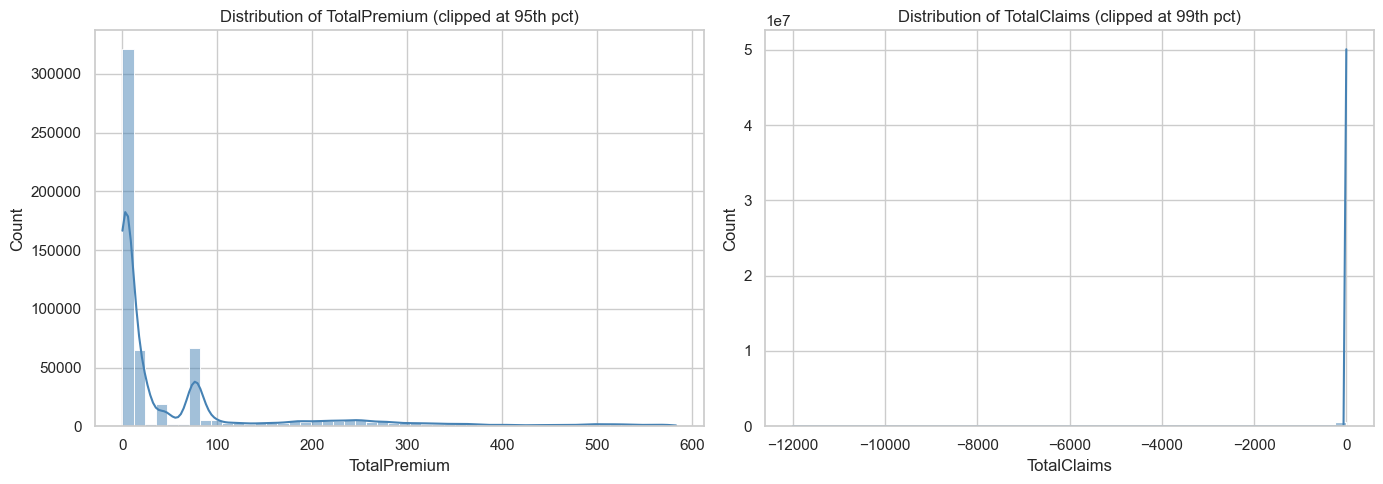

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_numeric_distribution(df, 'TotalPremium', clip_quantile=0.95, ax=axes[0])
plot_numeric_distribution(df, 'TotalClaims', clip_quantile=0.99, ax=axes[1])
plt.show()

c:\Users\user 1\Desktop\insurance-risk-analytics\notebooks\..\src\eda_utils.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="mako")


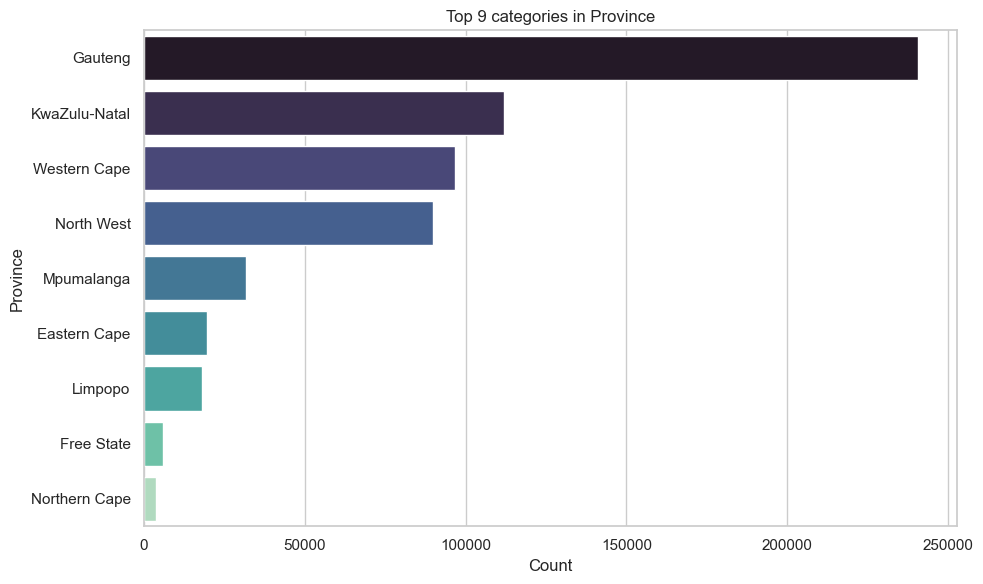

In [8]:
plot_categorical_counts(df, 'Province', top_n=9)
plt.show()

c:\Users\user 1\Desktop\insurance-risk-analytics\notebooks\..\src\eda_utils.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="mako")


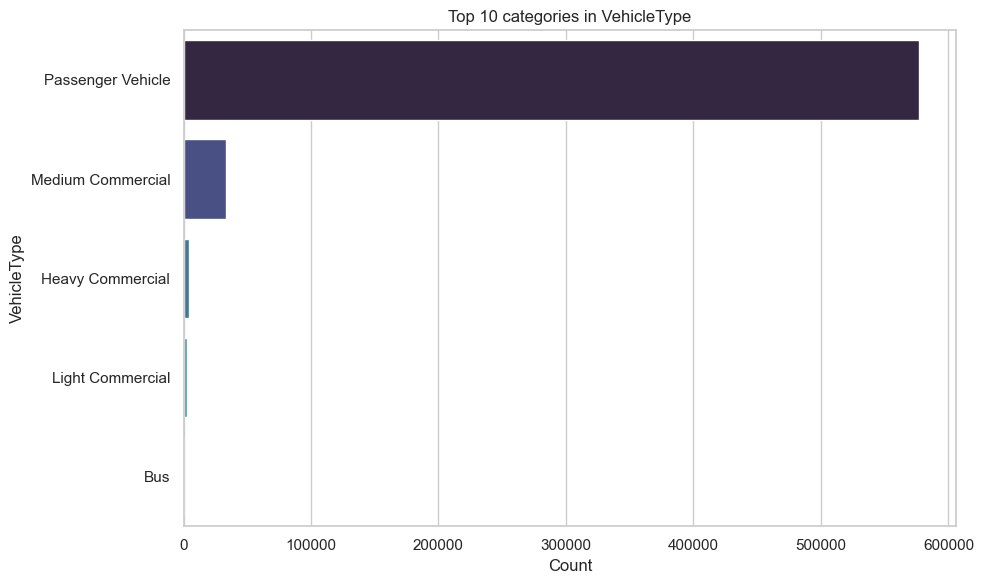

In [9]:
plot_categorical_counts(df, 'VehicleType', top_n=10)
plt.show()

c:\Users\user 1\Desktop\insurance-risk-analytics\notebooks\..\src\eda_utils.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="mako")


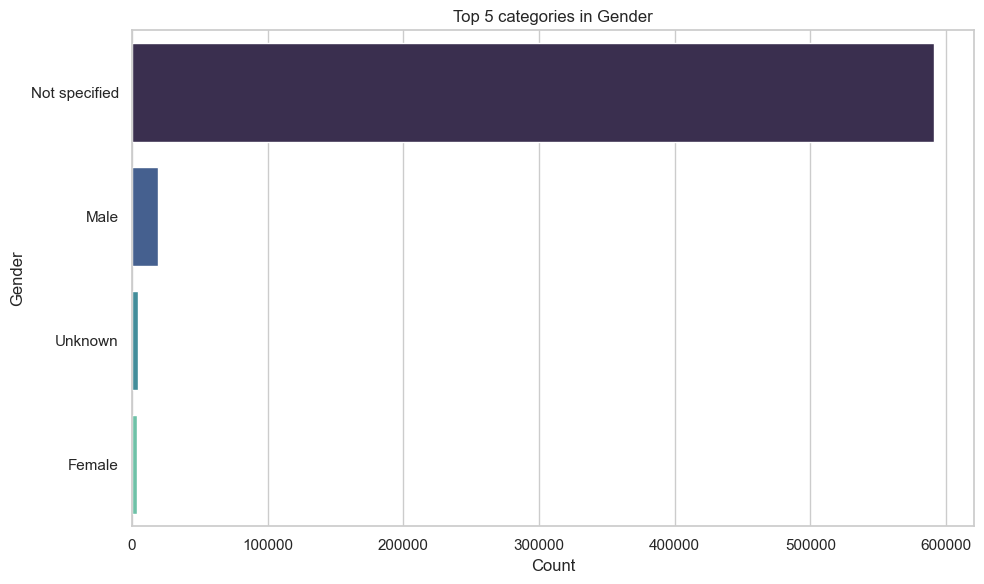

In [10]:
plot_categorical_counts(df, 'Gender', top_n=5)
plt.show()

## 4. Bivariate / Multivariate Analysis

Relationships between TotalPremium and TotalClaims, and by ZipCode (PostalCode), using scatter plots and correlation matrices.

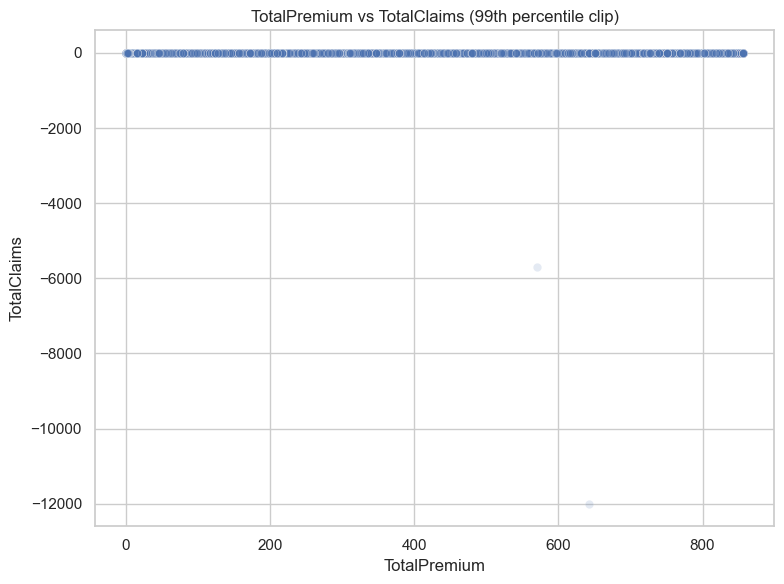

In [11]:
# Scatter plot: TotalPremium vs TotalClaims (clipped to 99th percentile to reduce distortion from extreme outliers)
clip_p = df['TotalPremium'].quantile(0.99)
clip_c = df['TotalClaims'].quantile(0.99)
plot_df = df[(df['TotalPremium'] <= clip_p) & (df['TotalClaims'] <= clip_c)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='TotalPremium', y='TotalClaims', alpha=0.15, ax=ax)
ax.set_title('TotalPremium vs TotalClaims (99th percentile clip)')
plt.tight_layout()
plt.show()

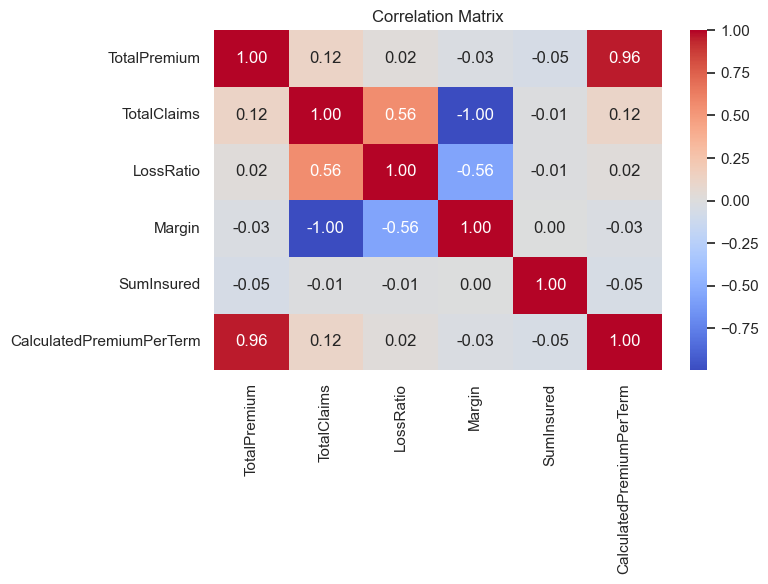

In [12]:
correlation_matrix(df, ['TotalPremium', 'TotalClaims', 'LossRatio', 'Margin', 'SumInsured', 'CalculatedPremiumPerTerm'])
plt.show()

In [13]:
# Top 15 postal codes by loss ratio (min 50 policies to avoid noise from tiny samples)
zip_summary = loss_ratio_by_group(df, 'PostalCode')
zip_summary = zip_summary[zip_summary['policy_count'] >= 50]
zip_summary.head(15)

,total_premium,total_claims,policy_count,loss_ratio
PostalCode,,,,
9756,8973.928993,157520.359649,99,17.553110
4008,6986.402716,87568.421053,83,12.534122
2920,7980.388158,96705.140351,55,12.117849
5050,18655.658325,207824.210526,175,11.140009
1751,9410.829693,103434.824561,77,10.991042
1805,17838.733979,173658.622807,165,9.734919
9323,5202.090351,44736.842105,55,8.599782
81,65870.647023,464492.947368,603,7.051592
1665,8992.151986,61729.631579,80,6.864834


## 5. Geographic Trends

Compare cover type, premium, and vehicle make across provinces.

In [14]:
province_summary = df.groupby('Province').agg(
    avg_premium=('TotalPremium', 'mean'),
    avg_claims=('TotalClaims', 'mean'),
    policy_count=('TotalPremium', 'size')
)
province_summary['loss_ratio'] = df.groupby('Province').apply(lambda g: g['TotalClaims'].sum() / g['TotalPremium'].sum())
province_summary.sort_values('loss_ratio', ascending=False)

,avg_premium,avg_claims,policy_count,loss_ratio
Province,,,,
Gauteng,99.903115,116.209994,240782,1.163227
Western Cape,101.388071,105.854428,96758,1.044052
KwaZulu-Natal,118.286470,120.883247,111896,1.021953
North West,83.414160,62.291592,89799,0.746775
Mpumalanga,89.577486,64.295629,31663,0.717765
Limpopo,85.364235,55.077626,18009,0.645207
Eastern Cape,108.677905,68.361316,19694,0.629027
Free State,87.889960,44.837307,5932,0.510153
Northern Cape,86.894887,24.565059,3643,0.282699


c:\Users\user 1\Desktop\insurance-risk-analytics\notebooks\..\src\eda_utils.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary["loss_ratio"], y=summary.index, ax=ax, palette="rocket")


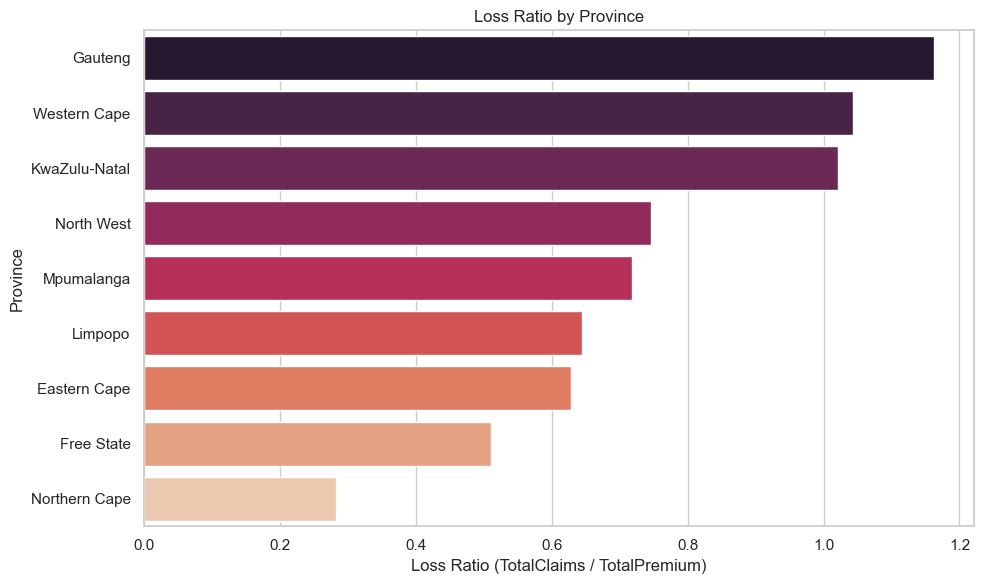

In [15]:
plot_loss_ratio_by_group(df, 'Province', title='Loss Ratio by Province')
plt.show()

In [16]:
# Most common cover type by province (creative insight plot)
top_cover_by_province = df.groupby(['Province', 'CoverType']).size().reset_index(name='count')
top_cover_by_province = top_cover_by_province.loc[top_cover_by_province.groupby('Province')['count'].idxmax()]
top_cover_by_province.sort_values('count', ascending=False)

,Province,CoverType,count
45,Gauteng,Own Damage,25416
69,KwaZulu-Natal,Third Party,11723
152,Western Cape,Third Party,10363
118,North West,Third Party,9124
89,Mpumalanga,Cleaning and Removal of Accident Debris,3386
4,Eastern Cape,Cleaning and Removal of Accident Debris,1967
73,Limpopo,Cleaning and Removal of Accident Debris,1816
20,Free State,Cleaning and Removal of Accident Debris,580
123,Northern Cape,Cleaning and Removal of Accident Debris,338


## 6. Outlier Detection

Box plots on key numerical features.

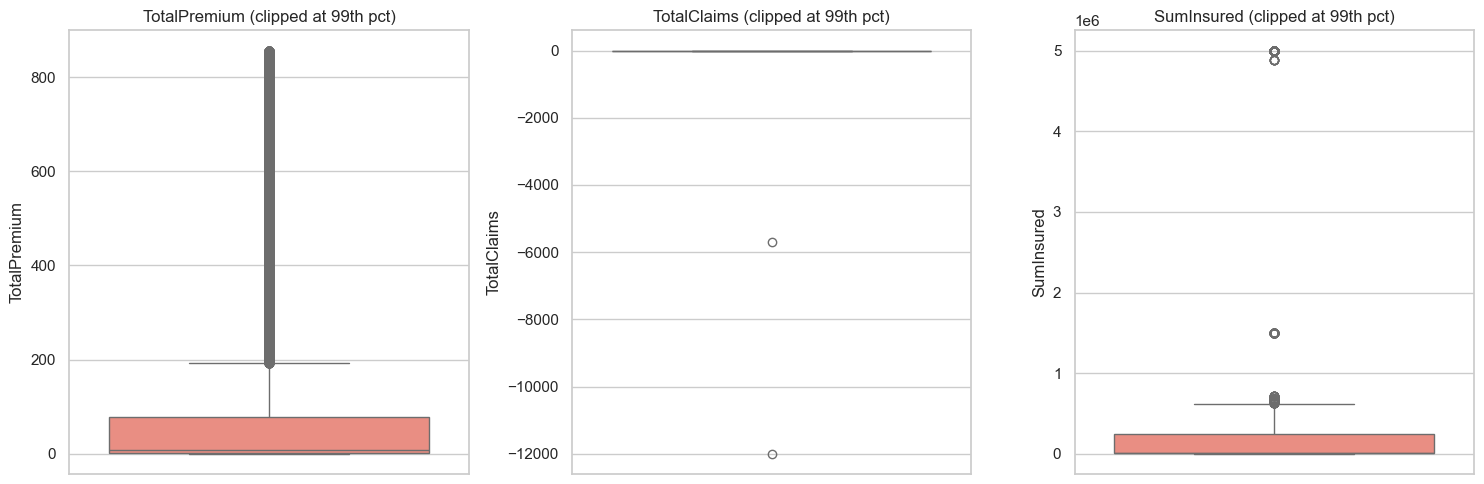

In [17]:
plot_outliers_boxplot(df, ['TotalPremium', 'TotalClaims', 'SumInsured'], clip_quantile=0.99)
plt.show()

## 7. Temporal Trends

Did claim frequency or severity change over the 18-month observation window?

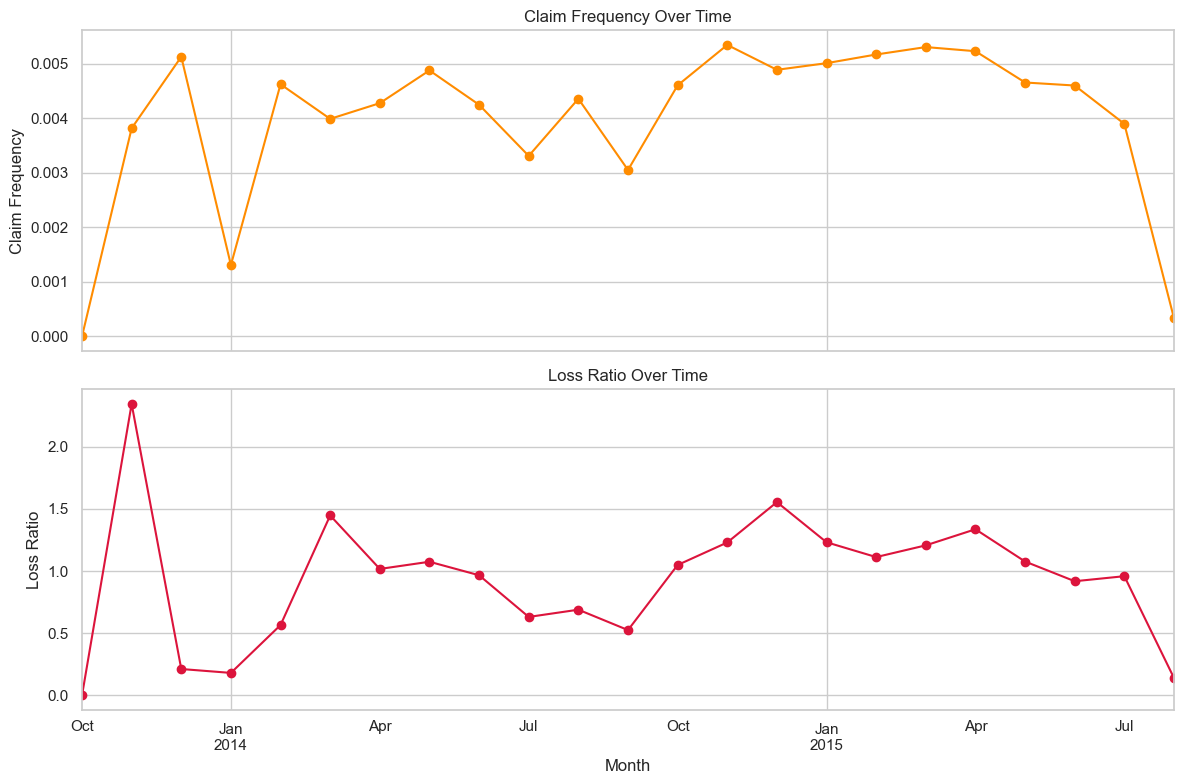

In [18]:
plot_monthly_trend(df)
plt.show()

In [19]:
monthly_trend(df)

,total_premium,total_claims,claim_count,policy_count,claim_frequency,loss_ratio
month,,,,,,
2013-10,3.710635e+02,0.000000e+00,0,36,0.000000,0.000000
2013-11,2.159196e+04,5.058508e+04,2,524,0.003817,2.342773
2013-12,4.366881e+04,9.283386e+03,3,585,0.005128,0.212586
2014-01,5.669357e+04,1.028016e+04,1,764,0.001309,0.181328
2014-02,6.339680e+04,3.588042e+04,4,865,0.004624,0.565966
2014-03,1.011856e+05,1.463812e+05,6,1504,0.003989,1.446661
2014-04,2.368827e+05,2.408658e+05,13,3039,0.004278,1.016814
2014-05,3.785201e+05,4.067548e+05,23,4715,0.004878,1.074592
2014-06,4.888278e+05,4.722523e+05,25,5885,0.004248,0.966091


## 8. Vehicle Make/Model Analysis

Which vehicle makes are associated with the highest and lowest average claim amounts (among policies with at least one claim)?

In [20]:
top_makes, bottom_makes = top_bottom_by_claims(df, group_col='make', n=10)
print("Highest average claims by make:")
print(top_makes)
print("\nLowest average claims by make:")
print(bottom_makes)

Highest average claims by make:
make
POLARSUN                               125197.843333
HYUNDAI                                 56663.492325
B.A.W                                   47856.245614
GOLDEN JOURNEY                          46169.723522
MERCEDES-BENZ                           34079.340852
IVECO                                   34030.040271
CMC                                     33096.374263
AUDI                                    31834.675504
VOLKSWAGEN                              29708.878625
SUZUKI                                  28152.799708
Name: TotalClaims, dtype: float64

Lowest average claims by make:
make
FORD                                    2040.473684
MITSUBISHI                              2378.596491
NISSAN                                 10248.199263
SAIC                                   11333.600000
FOTON                                  12147.263158
TOYOTA                                 13029.381579
JINBEI                                 14314.55597

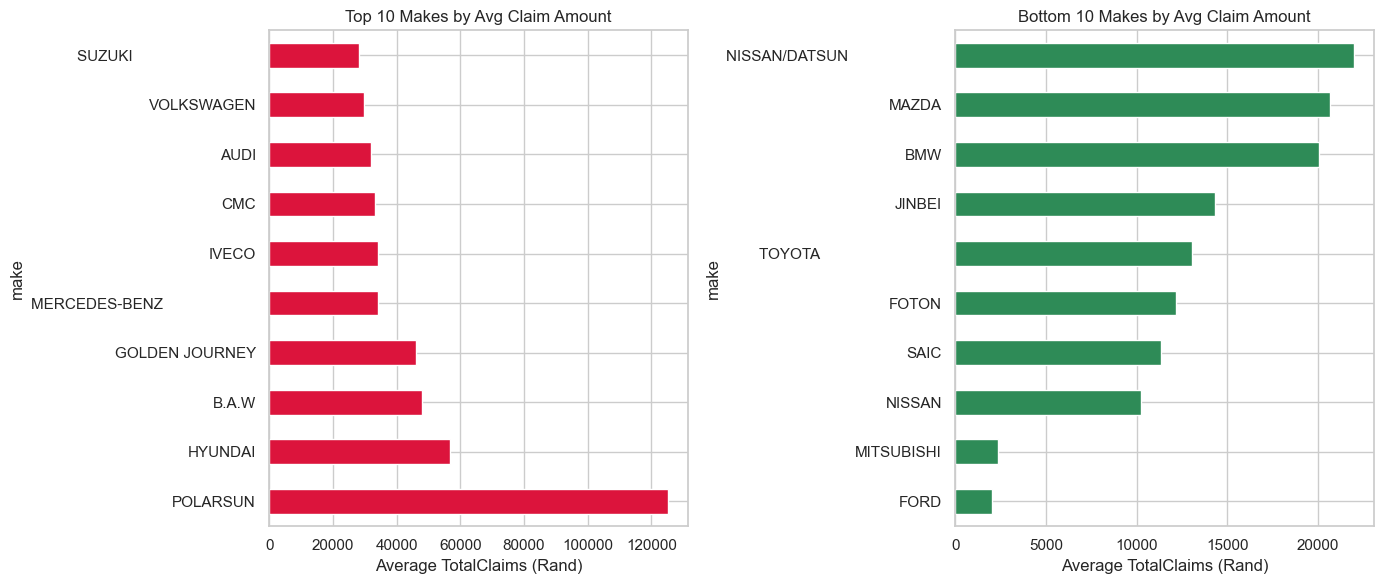

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_makes.plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title('Top 10 Makes by Avg Claim Amount')
axes[0].set_xlabel('Average TotalClaims (Rand)')

bottom_makes.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Bottom 10 Makes by Avg Claim Amount')
axes[1].set_xlabel('Average TotalClaims (Rand)')
plt.tight_layout()
plt.show()

## 9. Key Findings Summary

_Fill in with your specific numbers once you've run this notebook end-to-end on your machine:_

- **Overall portfolio loss ratio:** `overall_loss_ratio(df)` → run and report the value here.
- **Loss ratio varies by Province** — see Section 5; note which provinces run hottest.
- **Loss ratio by Gender** — compute similarly to Province and report here.
- **Outliers** are present in TotalClaims (max value far above the 75th percentile) and SumInsured — both were clipped for visualization but retained in modeling data.
- **Temporal trend** — describe whether claim frequency/severity trended up, down, or stayed flat across the 18 months based on the plot above.
- **Vehicle makes** — name the highest and lowest average-claim makes from Section 8.

In [22]:
print(f"Overall portfolio loss ratio: {overall_loss_ratio(df):.4f}")

gender_summary = loss_ratio_by_group(df, 'Gender')
print("\nLoss ratio by Gender:")
print(gender_summary)

Overall portfolio loss ratio: 1.0021

Loss ratio by Gender:
               total_premium  total_claims  policy_count  loss_ratio
Gender                                                              
Not specified   5.920782e+07  6.007638e+07        591068    1.014670
Female          3.044806e+05  2.472774e+05          3404    0.812129
Male            1.606618e+06  1.242916e+06         19083    0.773623
Unknown         8.241871e+05  5.064931e+05          4621    0.614537
